In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from IPython.display import display, clear_output

from CFD import exact_riemann_flux, muscl_reconstruction, strang_update, reflective_bc, transmissive_bc, create_explosion_initial_condition
from simulation.simulator import Simulator

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

pv.set_jupyter_backend("static")

Using device: cuda
CUDA device: NVIDIA GeForce GTX 1660 SUPER


In [2]:
# reference unit
rho0 = 1.2
p0   = 1e5
u0 = (p0 / rho0)**0.5

#Constant parameters
#z, y, x
RESOLUTION = 150, 150, 150

X_DOMAIN = [0, 1] # 1 m
Y_DOMAIN = [0, 1] # 1 m
Z_DOMAIN = [0, 1] # 1 m
T_DOMAIN = [0, 1.5]
DX = (X_DOMAIN[1] - X_DOMAIN[0]) / RESOLUTION[2]
DY = (Y_DOMAIN[1] - Y_DOMAIN[0]) / RESOLUTION[1]
DZ = (Z_DOMAIN[1] - Z_DOMAIN[0]) / RESOLUTION[0]

CFL_COEFFICIENT = 0.8
GAMMA = 1.4
TOL = 1e-6

# Initial Conditions
rho_inner_phy = 1.225 #(kg/m³)
p_inner_phy = 1e7 #(pa)
rho_outer_phy = 1.225 #(kg/m³)
p_outer_phy = 101325 #(pa)

# convert to reference unit
rho_inner = rho_inner_phy / rho0
p_inner = p_inner_phy / p0
rho_outer = rho_outer_phy / rho0
p_outer = p_outer_phy / p0

sigma = 0.1

In [3]:
sim = Simulator(
    dx=DX,
    dy=DY,
    dz=DZ,
    riemann_solver=exact_riemann_flux,
    reconstruction_method=muscl_reconstruction,
    boundary_function=reflective_bc,
    update_method=strang_update,
    dimension=3
)


CELL = create_explosion_initial_condition(
    nx = RESOLUTION[2],
    ny = RESOLUTION[1],
    nz = RESOLUTION[0],
    x_domain = X_DOMAIN,
    y_domain = Y_DOMAIN,
    z_domain = Z_DOMAIN,
    rho_inner = rho_inner,
    p_inner = p_inner,
    rho_outer = rho_outer,
    p_outer = p_outer,
    sigma = sigma,
    noise = 0.0,
    device = device
)


2026-02-11 18:49:51.675 (   0.855s) [    77435ABFD740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


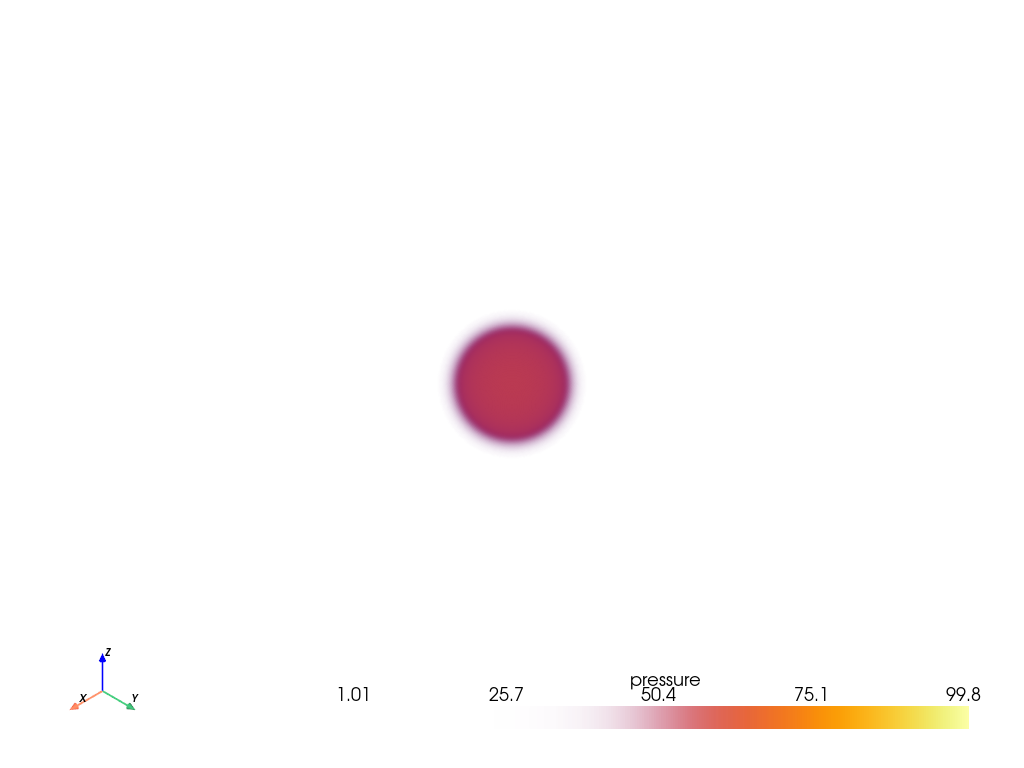

In [4]:
# visualize the initial condition
grid = pv.ImageData()

# VTK 규칙: cell data → dimensions = cell + 1 (x, y, z 순서)
grid.dimensions = (RESOLUTION[2] + 1, RESOLUTION[1] + 1, RESOLUTION[0] + 1)
grid.spacing = (DX, DY, DZ)
grid.origin = (X_DOMAIN[0], Y_DOMAIN[0], Z_DOMAIN[0])

# CELL(Z, Y, X) -> VTK(X, Y, Z) 축 정렬
pressure = CELL[..., 4].cpu().numpy()
pressure_vtk = np.transpose(pressure, (2, 1, 0))

grid.cell_data["pressure"] = pressure_vtk.flatten(order="F")

plotter = pv.Plotter(off_screen=True)
plotter.add_volume(grid, scalars="pressure", cmap="inferno", opacity="sigmoid")
plotter.add_axes()

plotter.show(jupyter_backend="static")

In [5]:
def update_grid(grid, CELL):
    rho = CELL[..., 0].cpu().numpy()
    speed = np.linalg.norm(CELL[..., 1:4].cpu().numpy(), axis=-1)
    pressure = CELL[..., 4].cpu().numpy()

    rho_vtk = np.transpose(rho, (2, 1, 0))
    speed_vtk = np.transpose(speed, (2, 1, 0))
    pressure_vtk = np.transpose(pressure, (2, 1, 0))

    grid.cell_data["density"] = rho_vtk.flatten(order="F")
    grid.cell_data["speed"] = speed_vtk.flatten(order="F")
    grid.cell_data["pressure"] = pressure_vtk.flatten(order="F")

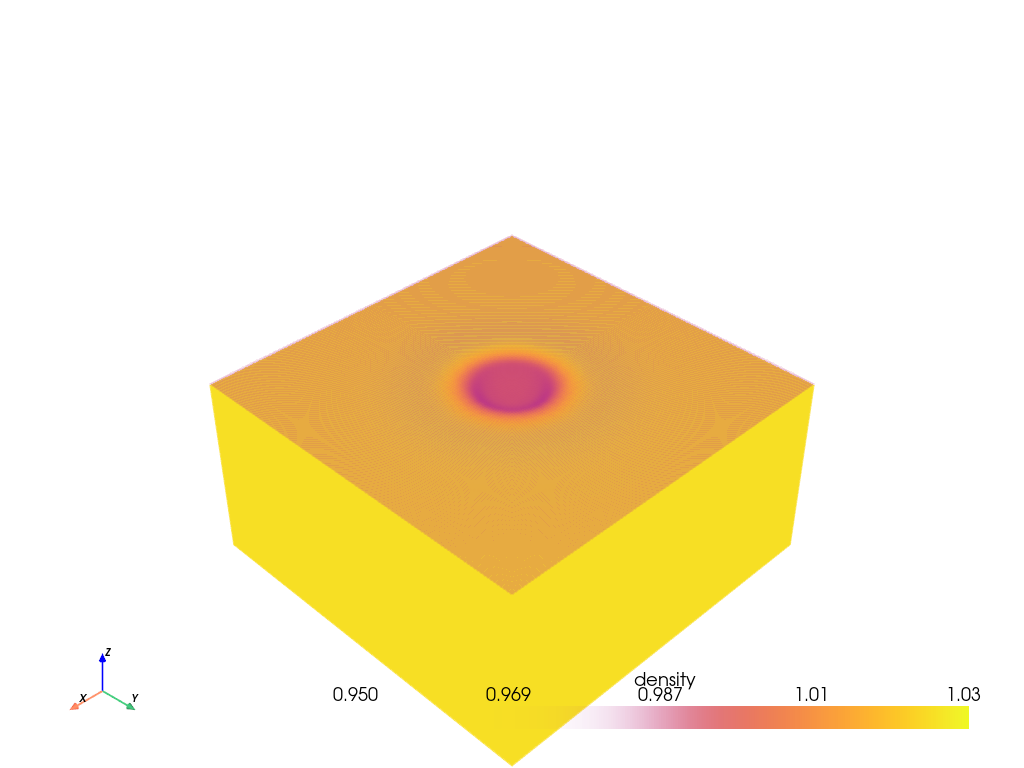

t = 0.003


KeyboardInterrupt: 

In [6]:
grid = pv.ImageData()

# VTK 규칙: cell data → dimensions = cell + 1 (x, y, z 순서)
grid.dimensions = (RESOLUTION[2] + 1, RESOLUTION[1] + 1, RESOLUTION[0] + 1)
grid.spacing = (DX, DY, DZ)
grid.origin = (X_DOMAIN[0], Y_DOMAIN[0], Z_DOMAIN[0])

# CELL(Z, Y, X) -> VTK(X, Y, Z) 축 정렬
rho = CELL[..., 0].cpu().numpy()
speed = np.linalg.norm(CELL[..., 1:4].cpu().numpy(), axis=-1)
pressure = CELL[..., 4].cpu().numpy()

rho_vtk = np.transpose(rho, (2, 1, 0))
speed_vtk = np.transpose(speed, (2, 1, 0))
pressure_vtk = np.transpose(pressure, (2, 1, 0))

grid.cell_data["density"] = rho_vtk.flatten(order="F")
grid.cell_data["speed"] = speed_vtk.flatten(order="F")
grid.cell_data["pressure"] = pressure_vtk.flatten(order="F")

# plotter는 한 번만 생성
plotter = pv.Plotter(off_screen=True)
plotter.add_volume(grid, scalars="density", cmap="inferno", opacity="sigmoid")
plotter.add_axes()


t = T_DOMAIN[0]

while t < T_DOMAIN[1]:
    CELL, dt = sim.update(CELL)
    t += dt

    #update the center rho, p to maintain the explosion
    #CELL[..., 0] = torch.max(CELL[..., 0], source[..., 0])
    #CELL[..., 4] = torch.max(CELL[..., 4], source[..., 4])

    rho = CELL[..., 0].cpu().numpy()
    rho_min = np.min(rho)
    rho[RESOLUTION[0]//2:, :, :] = rho_min
    rho_vtk = np.transpose(rho, (2, 1, 0))
    grid.cell_data["density"][:] = rho_vtk.flatten(order="F")

    clear_output(wait=True)
    plotter.clear()
    plotter.add_volume(grid, scalars="density", cmap="plasma", opacity="sigmoid")
    plotter.add_axes()
    plotter.show(jupyter_backend="static")
    print(f"t = {t:.3f}")